# Large-FOV Nuclear Segmentation and Analysis Pipeline

This notebook builds a **modular, HPC-friendly analysis pipeline** for stitched large-field-of-view microscopy data.

## Goals
- Segment nuclei across **all time points and z-planes** using a U-Net
- Build a reusable **segmentation/object table**
- Group nuclei across z within each time point
- Select the **largest cross-sectional area** per nucleus per time point
- Exclude likely **multi-nucleus droplets**
- Assign **tile-based acquisition time offsets** for stitched images
- Track nuclei across time with a movement tolerance
- Run **Fiji-equivalent cumulative halo analysis**
- Leave the pipeline flexible for **radial sweep** and other downstream analyses

## Design principles
- **Segmentation is separate from downstream analysis**
- **GPU** is used for U-Net inference
- **CPU / multicore** is used for labeling, grouping, tracking, and measurements
- Intermediate results are written to disk so stages can be rerun independently


## 1. Imports

In [1]:

from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
import json
import math
import os
import time

from joblib import Parallel, delayed
import numpy as np
import pandas as pd

from scipy import ndimage as ndi
from scipy.spatial import cKDTree
from skimage import measure, morphology

# Optional imports
try:
    import tensorflow as tf
except Exception:
    tf = None

try:
    import tifffile as tiff
except Exception:
    tiff = None


2026-04-14 12:28:41.269377: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 12:28:41.269432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 12:28:41.308376: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 12:28:41.363534: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 12:28:53.798172: W tensorflow/compiler/tf2

## 2. Configuration

In [2]:
def get_n_workers() -> int:
    return int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))


@dataclass
class PipelineConfig:
    # -------------------------
    # Root paths
    # -------------------------
    project_root: str = "/home/tdeibert/Data/Machine_Learning_Dev/"
    model_subdir: str = "Models"
    model_name: str = "unet_droplet_nucleus_best_1.2.h5"
    image_subdir: str = "Images"
    input_image_name: str = "control_extract_1.1.tif"
    output_subdir: str = "Outputs"

    # -------------------------
    # Imaging
    # -------------------------
    pixel_size_um: float = 0.108
    z_step_um: float = 1.0
    nuclear_channel_index: int = 1
    membrane_channel_index: int = 0

    # -------------------------
    # Halo analysis
    # -------------------------
    halo_step_px: int = 4
    n_halos: int = 4
    erosion_px: int = 4

    # -------------------------
    # Grouping / tracking
    # -------------------------
    z_group_tolerance_um: float = 1.0
    time_track_tolerance_um: float = 5.0
    multi_nucleus_exclusion_um: float = 10.0

    # -------------------------
    # Stitched acquisition layout
    # -------------------------
    tile_rows: int = 2
    tile_cols: int = 3
    minutes_per_tile: float = 1.0
    serpentine_scan: bool = True

    # -------------------------
    # Segmentation
    # -------------------------
    prediction_threshold: float = 0.5
    min_nucleus_area_px: int = 10
    nucleus_hole_size_px: int = 100
    nucleus_opening_radius_px: int = 1
    batch_size: int = 8
    use_mixed_precision: bool = False
    patch_size: int = 512
    patch_stride: int = 256
    background_class_index: int = 0
    droplet_class_index: int = 1
    nucleus_class_index: int = 2

    # -------------------------
    # HPC
    # -------------------------
    n_workers: Optional[int] = None

    def __post_init__(self):
        if self.n_workers is None:
            self.n_workers = min(get_n_workers(), 16)

    # -------------------------
    # Derived unit conversions
    # -------------------------
    @property
    def z_group_tolerance_px(self) -> float:
        return self.z_group_tolerance_um / self.pixel_size_um

    @property
    def time_track_tolerance_px(self) -> float:
        return self.time_track_tolerance_um / self.pixel_size_um

    @property
    def multi_nucleus_exclusion_px(self) -> float:
        return self.multi_nucleus_exclusion_um / self.pixel_size_um

    # -------------------------
    # Base paths
    # -------------------------
    @property
    def project_root_path(self) -> Path:
        return Path(self.project_root)

    @property
    def model_path(self) -> Path:
        return self.project_root_path / self.model_subdir / self.model_name

    @property
    def input_image_path(self) -> Path:
        return self.project_root_path / self.image_subdir / self.input_image_name

    @property
    def output_dir(self) -> Path:
        return self.project_root_path / self.output_subdir

    # -------------------------
    # Output subdirectories
    # -------------------------
    @property
    def seg_dir(self) -> Path:
        return self.output_dir / "segmentation"

    @property
    def obj_dir(self) -> Path:
        return self.output_dir / "objects"

    @property
    def track_dir(self) -> Path:
        return self.output_dir / "tracking"

    @property
    def analysis_dir(self) -> Path:
        return self.output_dir / "analysis"

    @property
    def qc_dir(self) -> Path:
        return self.output_dir / "qc"

    # -------------------------
    # Segmentation artifact paths
    # -------------------------
    @property
    def segmentation_index_path(self) -> Path:
        return self.seg_dir / "segmentation_index.pkl"

    @property
    def segmentation_class_hyperstack_path(self) -> Path:
        return self.seg_dir / "segmentation_class_hyperstack.tif"

    @property
    def segmentation_label_hyperstack_path(self) -> Path:
        return self.seg_dir / "segmentation_label_hyperstack.tif"

    @property
    def nucleus_instance_hyperstack_path(self) -> Path:
        return self.seg_dir / "nucleus_instance_hyperstack.tif"

    @property
    def droplet_instance_hyperstack_path(self) -> Path:
        return self.seg_dir / "droplet_instance_hyperstack.tif"

    @property
    def segmentation_roi_table_path(self) -> Path:
        return self.seg_dir / "segmentation_roi_table.pkl"


cfg = PipelineConfig()

for p in [
    cfg.output_dir,
    cfg.seg_dir,
    cfg.obj_dir,
    cfg.track_dir,
    cfg.analysis_dir,
    cfg.qc_dir,
]:
    p.mkdir(parents=True, exist_ok=True)

cfg

PipelineConfig(project_root='/home/tdeibert/Data/Machine_Learning_Dev/', model_subdir='Models', model_name='unet_droplet_nucleus_best_1.2.h5', image_subdir='Images', input_image_name='control_extract_1.1.tif', output_subdir='Outputs', pixel_size_um=0.108, z_step_um=1.0, nuclear_channel_index=1, membrane_channel_index=0, halo_step_px=4, n_halos=4, erosion_px=4, z_group_tolerance_um=1.0, time_track_tolerance_um=5.0, multi_nucleus_exclusion_um=10.0, tile_rows=2, tile_cols=3, minutes_per_tile=1.0, serpentine_scan=True, prediction_threshold=0.5, min_nucleus_area_px=10, nucleus_hole_size_px=100, nucleus_opening_radius_px=1, batch_size=8, use_mixed_precision=False, patch_size=512, patch_stride=256, background_class_index=0, droplet_class_index=1, nucleus_class_index=2, n_workers=16)

## 3. Save / load configuration

In [3]:

def save_config(config: PipelineConfig, out_path: Path) -> None:
    out_path.write_text(json.dumps(asdict(config), indent=2))


def load_config(in_path: Path) -> PipelineConfig:
    data = json.loads(in_path.read_text())
    return PipelineConfig(**data)


save_config(cfg, cfg.output_dir / "pipeline_config.json")


## 4. GPU setup

In [4]:

def configure_tensorflow_for_gpu(config: PipelineConfig) -> None:
    if tf is None:
        print("TensorFlow not available.")
        return

    gpus = tf.config.list_physical_devices("GPU")
    print("GPUs found:", gpus)

    if config.use_mixed_precision:
        try:
            from tensorflow.keras import mixed_precision
            mixed_precision.set_global_policy("mixed_float16")
            print("Mixed precision enabled.")
        except Exception as e:
            print("Could not enable mixed precision:", e)

    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as e:
            print("Could not set memory growth:", e)

configure_tensorflow_for_gpu(cfg)


GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 5. Image loading helpers

This notebook assumes image axes are:

`T × Z × C × Y × X`


In [5]:

def load_image_5d(image_path: Union[str, Path]) -> np.ndarray:
    if tiff is None:
        raise ImportError("tifffile is required to load TIFF data.")
    arr = tiff.imread(image_path)
    print("Loaded image shape:", arr.shape)
    return arr


def get_nuclear_plane(img_5d: np.ndarray, t: int, z: int, config: PipelineConfig) -> np.ndarray:
    return img_5d[t, z, config.nuclear_channel_index]


def get_membrane_plane(img_5d: np.ndarray, t: int, z: int, config: PipelineConfig) -> np.ndarray:
    return img_5d[t, z, config.membrane_channel_index]


def get_full_plane_yxc(img_5d: np.ndarray, t_idx: int, z_idx: int) -> np.ndarray:
    """Return a full 3-channel plane in (Y, X, C) format from a (T, Z, C, Y, X) image."""
    plane = img_5d[t_idx, z_idx]
    return np.moveaxis(plane, 0, -1)


## 6. U-Net inference

In [6]:

def load_unet_model(model_path: Union[str, Path]):
    if tf is None:
        raise ImportError("TensorFlow is not available.")
    return tf.keras.models.load_model(model_path, compile=False)


def preprocess_patch_for_model(patch: np.ndarray) -> np.ndarray:
    x = patch.astype(np.float32)
    max_val = np.max(x)
    if max_val > 0:
        x = x / max_val
    return x


def generate_patch_starts(length: int, patch_size: int, stride: int) -> List[int]:
    """
    Generate patch start positions that always include the image end.
    """
    starts = list(range(0, max(length - patch_size + 1, 1), stride))
    if not starts:
        starts = [0]

    last_start = length - patch_size
    if last_start < 0:
        last_start = 0

    if starts[-1] != last_start:
        starts.append(last_start)

    return sorted(set(starts))


def extract_overlapping_patches(
    image_yxc: np.ndarray,
    patch_size: int = 512,
    stride: int = 256,
) -> Tuple[List[np.ndarray], List[Tuple[int, int]]]:
    """
    Extract overlapping patches from a preprocessed full plane.
    Returns patches and top-left coordinates.
    """
    h, w, c = image_yxc.shape
    y_starts = generate_patch_starts(h, patch_size, stride)
    x_starts = generate_patch_starts(w, patch_size, stride)

    patches: List[np.ndarray] = []
    coords: List[Tuple[int, int]] = []

    for y0 in y_starts:
        for x0 in x_starts:
            patch = image_yxc[y0:y0 + patch_size, x0:x0 + patch_size, :]
            patches.append(patch)
            coords.append((y0, x0))

    return patches, coords


def predict_patch_probabilities(model, batch_patches: np.ndarray) -> np.ndarray:
    """
    Predict raw class probabilities for a batch of patches.
    Returns shape (B, H, W, C).
    """
    preds = model.predict(batch_patches, verbose=0)

    if preds.ndim != 4:
        raise ValueError(f"Unexpected prediction shape: {preds.shape}")

    if preds.shape[-1] == 1:
        fg = preds[..., 0]
        bg = 1.0 - fg
        preds = np.stack([bg, fg], axis=-1)

    return preds.astype(np.float32)


def stitch_probability_patches(
    patch_probs: List[np.ndarray],
    coords: List[Tuple[int, int]],
    image_shape: Tuple[int, int],
    n_classes: int,
    patch_size: int = 512,
) -> np.ndarray:
    """
    Stitch overlapping patch probabilities by averaging.
    Returns shape (H, W, C).
    """
    h, w = image_shape
    prob_sum = np.zeros((h, w, n_classes), dtype=np.float32)
    prob_count = np.zeros((h, w, 1), dtype=np.float32)

    for probs, (y0, x0) in zip(patch_probs, coords):
        y1 = y0 + patch_size
        x1 = x0 + patch_size
        prob_sum[y0:y1, x0:x1, :] += probs
        prob_count[y0:y1, x0:x1, :] += 1.0

    prob_map = prob_sum / np.maximum(prob_count, 1.0)
    return prob_map


def clean_nucleus_mask(
    nucleus_mask: np.ndarray,
    min_size_px: int = 300,
    hole_size_px: int = 100,
    opening_radius: int = 1,
) -> np.ndarray:
    mask = nucleus_mask.astype(bool)
    mask = morphology.remove_small_objects(mask, min_size=min_size_px)
    mask = morphology.remove_small_holes(mask, area_threshold=hole_size_px)

    if opening_radius > 0:
        mask = morphology.binary_opening(mask, footprint=morphology.disk(opening_radius))

    mask = ndi.binary_fill_holes(mask)
    return mask.astype(bool)


def segment_single_plane_with_overlap(
    plane_yxc: np.ndarray,
    model,
    config: PipelineConfig,
    patch_size: int = 512,
    stride: int = 256,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Segment one full plane using overlapping patches and probability stitching.

    Returns
    -------
    class_prob_map : (Y, X, C)
    class_label_map : (Y, X)
    nucleus_mask : (Y, X) bool
    nucleus_instance_labels : (Y, X) uint16
    """
   # plane_yxc = preprocess_full_plane_for_model(plane_yxc)
    h, w, c = plane_yxc.shape

    patches, coords = extract_overlapping_patches(
        plane_yxc,
        patch_size=patch_size,
        stride=stride,
    )
    patches = [preprocess_patch_for_model(p) for p in patches]
    
    patch_probs: List[np.ndarray] = []

    for i in range(0, len(patches), config.batch_size):
        batch = np.stack(patches[i:i + config.batch_size], axis=0)
        batch_pred = predict_patch_probabilities(model, batch)
        patch_probs.extend(batch_pred)

    n_classes = patch_probs[0].shape[-1]

    class_prob_map = stitch_probability_patches(
        patch_probs=patch_probs,
        coords=coords,
        image_shape=(h, w),
        n_classes=n_classes,
        patch_size=patch_size,
    )

    class_label_map = np.argmax(class_prob_map, axis=-1).astype(np.uint8)

# 🔥 NEW: use probability threshold instead of argmax
    nucleus_prob = class_prob_map[..., config.nucleus_class_index]


    nucleus_mask = class_label_map == config.nucleus_class_index
    nucleus_mask = clean_nucleus_mask(
        nucleus_mask,
        min_size_px=config.min_nucleus_area_px,
        hole_size_px=config.nucleus_hole_size_px,
        opening_radius=config.nucleus_opening_radius_px,
    )

    nucleus_instance_labels = measure.label(nucleus_mask, connectivity=2).astype(np.uint16)

    return class_prob_map, class_label_map, nucleus_mask, nucleus_instance_labels


def build_class_binary_stack(
    class_label_map: np.ndarray,
    config: PipelineConfig,
) -> np.ndarray:
    return np.stack(
        [
            class_label_map == config.background_class_index,
            class_label_map == config.droplet_class_index,
            class_label_map == config.nucleus_class_index,
        ],
        axis=0,
    ).astype(np.uint8)


def save_class_hyperstack_tiff(class_mask_5d: np.ndarray, out_path: Path) -> None:
    if tiff is None:
        raise ImportError("tifffile is required to save TIFF data.")
    tiff.imwrite(
        out_path,
        (class_mask_5d.astype(np.uint8) * 255),
        imagej=True,
        metadata={"axes": "TZCYX"},
    )


def save_label_hyperstack_tiff(label_4d: np.ndarray, out_path: Path) -> None:
    if tiff is None:
        raise ImportError("tifffile is required to save TIFF data.")
    tiff.imwrite(
        out_path,
        label_4d.astype(np.uint8),
        imagej=True,
        metadata={"axes": "TZYX"},
    )


def save_instance_hyperstack_tiff(instance_4d: np.ndarray, out_path: Path) -> None:
    if tiff is None:
        raise ImportError("tifffile is required to save TIFF data.")
    tiff.imwrite(
        out_path,
        instance_4d,
        imagej=True,
        metadata={"axes": "TZYX"},
    )


def regionprops_to_rows(
    labeled_mask: np.ndarray,
    t_idx: int,
    z_idx: int,
    class_id: int,
    class_name: str,
) -> List[Dict[str, Union[int, float, str]]]:
    rows: List[Dict[str, Union[int, float, str]]] = []
    for prop in measure.regionprops(labeled_mask):
        cy, cx = prop.centroid
        rows.append(
            {
                "t": t_idx,
                "z": z_idx,
                "class_id": class_id,
                "class_name": class_name,
                "label": int(prop.label),
                "centroid_x_px": float(cx),
                "centroid_y_px": float(cy),
                "area_px": int(prop.area),
                "bbox_min_row": int(prop.bbox[0]),
                "bbox_min_col": int(prop.bbox[1]),
                "bbox_max_row": int(prop.bbox[2]),
                "bbox_max_col": int(prop.bbox[3]),
            }
        )
    return rows


def run_segmentation_for_all_planes(
    img_5d: np.ndarray,
    model,
    config: PipelineConfig,
    save_binary_masks: bool = True,
) -> pd.DataFrame:
    records = []
    roi_rows: List[Dict[str, Union[int, float, str]]] = []
    T, Z = img_5d.shape[0], img_5d.shape[1]
    Y, X = img_5d.shape[-2], img_5d.shape[-1]

    class_mask_5d = np.zeros((T, Z, 3, Y, X), dtype=np.uint8)
    class_label_4d = np.zeros((T, Z, Y, X), dtype=np.uint8)
    nucleus_instance_4d = np.zeros((T, Z, Y, X), dtype=np.uint16)
    droplet_instance_4d = np.zeros((T, Z, Y, X), dtype=np.uint16)

    for t_idx in range(T):
        for z_idx in range(Z):
            plane_yxc = get_full_plane_yxc(img_5d, t_idx, z_idx)

            class_prob_map, class_label_map, nucleus_mask, nucleus_instance_labels = segment_single_plane_with_overlap(
                plane_yxc=plane_yxc,
                model=model,
                config=config,
                patch_size=config.patch_size,
                stride=config.patch_stride,
            )

            background_mask = class_label_map == config.background_class_index
            droplet_mask = class_label_map == config.droplet_class_index

            class_mask_5d[t_idx, z_idx, 0] = background_mask.astype(np.uint8)
            class_mask_5d[t_idx, z_idx, 1] = droplet_mask.astype(np.uint8)
            class_mask_5d[t_idx, z_idx, 2] = nucleus_mask.astype(np.uint8)

            class_label_4d[t_idx, z_idx] = class_label_map.astype(np.uint8)

            droplet_instances = measure.label(droplet_mask, connectivity=2).astype(np.uint16)

            nucleus_instance_4d[t_idx, z_idx] = nucleus_instance_labels.astype(np.uint16)
            droplet_instance_4d[t_idx, z_idx] = droplet_instances

            roi_rows.extend(
                regionprops_to_rows(
                    labeled_mask=nucleus_instance_labels,
                    t_idx=t_idx,
                    z_idx=z_idx,
                    class_id=config.nucleus_class_index,
                    class_name="nucleus",
                )
            )
            roi_rows.extend(
                regionprops_to_rows(
                    labeled_mask=droplet_instances,
                    t_idx=t_idx,
                    z_idx=z_idx,
                    class_id=config.droplet_class_index,
                    class_name="droplet",
                )
            )

            out_path = config.seg_dir / f"nuclear_mask_t{t_idx:03d}_z{z_idx:03d}.npy"
            if save_binary_masks:
                np.save(out_path, nucleus_mask.astype(np.uint8))

            records.append({
                "t": t_idx,
                "z": z_idx,
                "mask_path": str(out_path),
            })

    save_class_hyperstack_tiff(class_mask_5d, config.segmentation_class_hyperstack_path)
    save_label_hyperstack_tiff(class_label_4d, config.segmentation_label_hyperstack_path)
    save_instance_hyperstack_tiff(nucleus_instance_4d, config.nucleus_instance_hyperstack_path)
    save_instance_hyperstack_tiff(droplet_instance_4d, config.droplet_instance_hyperstack_path)

    roi_df = pd.DataFrame(roi_rows)
    roi_df.to_pickle(config.segmentation_roi_table_path)

    seg_index_df = pd.DataFrame(records)
    seg_index_df.to_pickle(config.segmentation_index_path)
    return seg_index_df


## 7. Object extraction from masks

In [7]:

def label_and_measure_objects(mask: np.ndarray, t_idx: int, z_idx: int, config: PipelineConfig) -> pd.DataFrame:
    labeled = measure.label(mask, connectivity=2)
    props = measure.regionprops(labeled)

    rows = []
    for prop in props:
        if prop.area < config.min_nucleus_area_px:
            continue

        cy, cx = prop.centroid
        rows.append({
            "t": t_idx,
            "z": z_idx,
            "label": int(prop.label),
            "centroid_x_px": float(cx),
            "centroid_y_px": float(cy),
            "area_px": int(prop.area),
            "bbox_min_row": int(prop.bbox[0]),
            "bbox_min_col": int(prop.bbox[1]),
            "bbox_max_row": int(prop.bbox[2]),
            "bbox_max_col": int(prop.bbox[3]),
        })

    return pd.DataFrame(rows)


def extract_objects_from_saved_masks(seg_index_df: pd.DataFrame, config: PipelineConfig) -> pd.DataFrame:
    all_rows = []

    for row in seg_index_df.itertuples(index=False):
        mask = np.load(row.mask_path).astype(bool)
        obj_df = label_and_measure_objects(mask, row.t, row.z, config)
        all_rows.append(obj_df)

    objects_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    objects_df.to_pickle(config.obj_dir / "plane_objects.pkl")
    return objects_df


## 8. Distance-based helpers

In [8]:

def euclidean_distance_px(x1: float, y1: float, x2: float, y2: float) -> float:
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def nearest_neighbor_matches(
    source_df: pd.DataFrame,
    target_df: pd.DataFrame,
    max_dist_px: float,
) -> List[Tuple[int, int, float]]:
    if source_df.empty or target_df.empty:
        return []

    source_xy = source_df[["centroid_x_px", "centroid_y_px"]].to_numpy()
    target_xy = target_df[["centroid_x_px", "centroid_y_px"]].to_numpy()

    tree = cKDTree(target_xy)
    dists, idxs = tree.query(source_xy, distance_upper_bound=max_dist_px)

    matches = []
    used_targets = set()

    order = np.argsort(dists)
    for i in order:
        dist = dists[i]
        j = idxs[i]
        if np.isinf(dist):
            continue
        if j in used_targets:
            continue
        matches.append((int(i), int(j), float(dist)))
        used_targets.add(int(j))

    return matches


## 9. Group nuclei across z within each time point

In [9]:

def group_nuclei_across_z(objects_df: pd.DataFrame, config: PipelineConfig) -> pd.DataFrame:
    if objects_df.empty:
        return pd.DataFrame()

    grouped_rows = []
    next_group_id = 1

    for t_idx, df_t in objects_df.groupby("t", sort=True):
        df_t = df_t.sort_values(["z", "label"]).reset_index(drop=True).copy()
        df_t["nucleus_3d_id"] = -1
        z_values = sorted(df_t["z"].unique())

        first_z = z_values[0]
        first_idx = df_t.index[df_t["z"] == first_z].tolist()
        for idx in first_idx:
            df_t.at[idx, "nucleus_3d_id"] = next_group_id
            next_group_id += 1

        for z_prev, z_curr in zip(z_values[:-1], z_values[1:]):
            prev_df = df_t[df_t["z"] == z_prev].reset_index()
            curr_df = df_t[df_t["z"] == z_curr].reset_index()

            matches = nearest_neighbor_matches(prev_df, curr_df, config.z_group_tolerance_px)
            matched_curr_global = set()

            for i_prev, i_curr, dist in matches:
                prev_global_idx = int(prev_df.loc[i_prev, "index"])
                curr_global_idx = int(curr_df.loc[i_curr, "index"])
                matched_curr_global.add(curr_global_idx)

                prev_group = df_t.at[prev_global_idx, "nucleus_3d_id"]
                if prev_group == -1:
                    prev_group = next_group_id
                    df_t.at[prev_global_idx, "nucleus_3d_id"] = prev_group
                    next_group_id += 1

                df_t.at[curr_global_idx, "nucleus_3d_id"] = prev_group

            for curr_global_idx in curr_df["index"].tolist():
                if curr_global_idx not in matched_curr_global and df_t.at[curr_global_idx, "nucleus_3d_id"] == -1:
                    df_t.at[curr_global_idx, "nucleus_3d_id"] = next_group_id
                    next_group_id += 1

        grouped_rows.append(df_t)

    grouped_z_df = pd.concat(grouped_rows, ignore_index=True)
    grouped_z_df.to_pickle(config.obj_dir / "grouped_z_objects.pkl")
    return grouped_z_df


## 10. Select the largest cross-sectional area in z

In [10]:
def select_best_z_per_nucleus(grouped_z_df: pd.DataFrame, config: PipelineConfig) -> pd.DataFrame:
    if grouped_z_df.empty:
        return pd.DataFrame()

    best_z_df = (
        grouped_z_df
        .sort_values(["t", "nucleus_3d_id", "area_px"], ascending=[True, True, False])
        .groupby(["t", "nucleus_3d_id"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    best_z_df.to_pickle(config.obj_dir / "best_z_nuclei.pkl")
    return best_z_df

## 11. Exclude likely multi-nucleus droplets

In [11]:

def flag_close_nuclei(best_z_df: pd.DataFrame, config: PipelineConfig) -> pd.DataFrame:
    if best_z_df.empty:
        return pd.DataFrame()

    out = []
    for t_idx, df_t in best_z_df.groupby("t", sort=True):
        df_t = df_t.copy().reset_index(drop=True)
        coords = df_t[["centroid_x_px", "centroid_y_px"]].to_numpy()
        tree = cKDTree(coords)
        close_flags = np.zeros(len(df_t), dtype=bool)

        for i, xy in enumerate(coords):
            neighbor_idx = tree.query_ball_point(xy, r=config.multi_nucleus_exclusion_px)
            neighbor_idx = [j for j in neighbor_idx if j != i]
            if len(neighbor_idx) > 0:
                close_flags[i] = True
                for j in neighbor_idx:
                    close_flags[j] = True

        df_t["valid_single_nucleus"] = ~close_flags
        out.append(df_t)

    filtered_df = pd.concat(out, ignore_index=True)
    filtered_df.to_pickle(config.obj_dir / "best_z_nuclei_with_exclusion.pkl")
    return filtered_df


## 12. Tile assignment and true acquisition time

In [12]:

def assign_tile_index_from_xy(
    x_px: float,
    y_px: float,
    image_width_px: int,
    image_height_px: int,
    config: PipelineConfig,
) -> Tuple[int, int, int]:
    tile_w = image_width_px / config.tile_cols
    tile_h = image_height_px / config.tile_rows

    col = min(int(x_px // tile_w), config.tile_cols - 1)
    row = min(int(y_px // tile_h), config.tile_rows - 1)

    if config.serpentine_scan:
        if row % 2 == 0:
            tile_index = row * config.tile_cols + col
        else:
            tile_index = row * config.tile_cols + (config.tile_cols - 1 - col)
    else:
        tile_index = row * config.tile_cols + col

    return row, col, tile_index

def add_tile_timing_metadata(nuclei_df: pd.DataFrame, img_5d: np.ndarray, config: PipelineConfig) -> pd.DataFrame:
    if nuclei_df.empty:
        return pd.DataFrame()

    image_height_px = img_5d.shape[-2]
    image_width_px = img_5d.shape[-1]

    out_rows = []
    for row in nuclei_df.itertuples(index=False):
        tile_row, tile_col, tile_index = assign_tile_index_from_xy(
            x_px=row.centroid_x_px,
            y_px=row.centroid_y_px,
            image_width_px=image_width_px,
            image_height_px=image_height_px,
            config=config
        )

        tile_offset_min = tile_index * config.minutes_per_tile
        true_time_min = row.t * (config.tile_rows * config.tile_cols * config.minutes_per_tile) + tile_offset_min

        d = row._asdict()
        d["tile_row"] = tile_row
        d["tile_col"] = tile_col
        d["tile_index"] = tile_index
        d["tile_offset_min"] = tile_offset_min
        d["true_time_min"] = true_time_min
        out_rows.append(d)

    timed_df = pd.DataFrame(out_rows)
    timed_df.to_pickle(config.track_dir / "best_z_nuclei_timed.pkl")
    return timed_df


## 13. Track nuclei across time

In [13]:

def assign_track_ids(timed_df: pd.DataFrame, config: PipelineConfig, valid_only: bool = True) -> pd.DataFrame:
    if timed_df.empty:
        return pd.DataFrame()

    df = timed_df.copy()
    if valid_only and "valid_single_nucleus" in df.columns:
        df = df[df["valid_single_nucleus"]].copy()

    df = df.sort_values(["t", "nucleus_3d_id"]).reset_index(drop=True)
    df["track_id"] = -1

    next_track_id = 1
    time_values = sorted(df["t"].unique())

    t0 = time_values[0]
    idx0 = df.index[df["t"] == t0].tolist()
    for idx in idx0:
        df.at[idx, "track_id"] = next_track_id
        next_track_id += 1

    for t_prev, t_curr in zip(time_values[:-1], time_values[1:]):
        prev_df = df[df["t"] == t_prev].reset_index()
        curr_df = df[df["t"] == t_curr].reset_index()

        matches = nearest_neighbor_matches(prev_df, curr_df, config.time_track_tolerance_px)
        matched_curr_global = set()

        for i_prev, i_curr, dist in matches:
            prev_global_idx = int(prev_df.loc[i_prev, "index"])
            curr_global_idx = int(curr_df.loc[i_curr, "index"])
            matched_curr_global.add(curr_global_idx)

            track_id = df.at[prev_global_idx, "track_id"]
            if track_id == -1:
                track_id = next_track_id
                df.at[prev_global_idx, "track_id"] = track_id
                next_track_id += 1

            df.at[curr_global_idx, "track_id"] = track_id

        for curr_global_idx in curr_df["index"].tolist():
            if curr_global_idx not in matched_curr_global and df.at[curr_global_idx, "track_id"] == -1:
                df.at[curr_global_idx, "track_id"] = next_track_id
                next_track_id += 1

    df.to_pickle(config.track_dir / "tracked_nuclei.pkl")
    return df


## 14. Fiji-equivalent cumulative halos

In [14]:

def build_cumulative_halo_masks(nucleus_mask: np.ndarray, config: PipelineConfig) -> Dict[str, np.ndarray]:
    dist_outside = ndi.distance_transform_edt(~nucleus_mask)
    cumulative = {"nucleus_mask": nucleus_mask.astype(bool)}

    for i in range(1, config.n_halos + 1):
        max_dist = i * config.halo_step_px
        cumulative[f"halo_{i}_cum"] = dist_outside <= max_dist

    for i in range(1, config.n_halos + 1):
        if i == 1:
            cumulative[f"ring_{i}"] = cumulative["halo_1_cum"] & (~nucleus_mask)
        else:
            cumulative[f"ring_{i}"] = cumulative[f"halo_{i}_cum"] & (~cumulative[f"halo_{i-1}_cum"])

    if config.erosion_px > 0:
        eroded = ndi.binary_erosion(nucleus_mask, structure=morphology.disk(config.erosion_px))
        cumulative["nucleus_eroded"] = eroded
    else:
        cumulative["nucleus_eroded"] = nucleus_mask.copy()

    cumulative["cytoplasm_mask"] = cumulative[f"halo_{config.n_halos}_cum"] & (~nucleus_mask)
    return cumulative

def mask_stats(intensity_image: np.ndarray, mask: np.ndarray) -> Dict[str, float]:
    area_px = int(mask.sum())
    if area_px == 0:
        return {"area_px": 0, "intden": 0.0, "mean_intensity": np.nan}
    vals = intensity_image[mask]
    return {
        "area_px": area_px,
        "intden": float(vals.sum()),
        "mean_intensity": float(vals.mean()),
    }

def measure_fiji_equivalent_halos(intensity_image: np.ndarray, nucleus_mask: np.ndarray, config: PipelineConfig) -> Dict[str, float]:
    masks = build_cumulative_halo_masks(nucleus_mask, config)
    out = {}

    nuc = mask_stats(intensity_image, masks["nucleus_mask"])
    for k, v in nuc.items():
        out[f"nucleus_{k}"] = v

    nuc_eroded = mask_stats(intensity_image, masks["nucleus_eroded"])
    for k, v in nuc_eroded.items():
        out[f"nucleus_eroded_{k}"] = v

    for i in range(1, config.n_halos + 1):
        stats = mask_stats(intensity_image, masks[f"halo_{i}_cum"])
        for k, v in stats.items():
            out[f"halo_{i}_cum_{k}"] = v

    for i in range(1, config.n_halos + 1):
        stats = mask_stats(intensity_image, masks[f"ring_{i}"])
        for k, v in stats.items():
            out[f"ring_{i}_{k}"] = v

    cyto = mask_stats(intensity_image, masks["cytoplasm_mask"])
    for k, v in cyto.items():
        out[f"cytoplasm_{k}"] = v

    nuclear_mean = out["nucleus_mean_intensity"]
    cytoplasm_mean = out["cytoplasm_mean_intensity"]

    out["nc_ratio"] = float(nuclear_mean / cytoplasm_mean) if np.isfinite(nuclear_mean) and np.isfinite(cytoplasm_mean) and cytoplasm_mean != 0 else np.nan
    out["nc_ratio_fraction"] = float(nuclear_mean / (nuclear_mean + cytoplasm_mean)) if np.isfinite(nuclear_mean) and np.isfinite(cytoplasm_mean) and (nuclear_mean + cytoplasm_mean) != 0 else np.nan
    return out


## 15. Recover a nucleus mask for a tracked object

In [15]:

def recover_nucleus_mask_from_plane(
    t_idx: int,
    z_idx: int,
    centroid_x_px: float,
    centroid_y_px: float,
    config: PipelineConfig,
) -> np.ndarray:
    mask_path = config.seg_dir / f"nuclear_mask_t{t_idx:03d}_z{z_idx:03d}.npy"
    mask = np.load(mask_path).astype(bool)

    labeled = measure.label(mask, connectivity=2)
    props = measure.regionprops(labeled)

    best_label = None
    best_dist = np.inf

    for prop in props:
        cy, cx = prop.centroid
        dist = euclidean_distance_px(cx, cy, centroid_x_px, centroid_y_px)
        if dist < best_dist:
            best_dist = dist
            best_label = prop.label

    if best_label is None:
        return np.zeros_like(mask, dtype=bool)

    return labeled == best_label


## 16. Run halo analysis for tracked nuclei

In [16]:

def _process_single_tracked_nucleus(row, img_5d: np.ndarray, config: PipelineConfig) -> dict:
    t_idx = int(row.t)
    z_idx = int(row.z)
    cx = float(row.centroid_x_px)
    cy = float(row.centroid_y_px)

    nucleus_mask = recover_nucleus_mask_from_plane(t_idx, z_idx, cx, cy, config)
    nuclear_plane = get_nuclear_plane(img_5d, t_idx, z_idx, config)

    halo_metrics = measure_fiji_equivalent_halos(
        intensity_image=nuclear_plane,
        nucleus_mask=nucleus_mask,
        config=config,
    )

    rec = row._asdict()
    rec.update(halo_metrics)
    rec["nucleus_area_um2"] = rec["nucleus_area_px"] * (config.pixel_size_um ** 2)
    rec["cytoplasm_area_um2"] = rec["cytoplasm_area_px"] * (config.pixel_size_um ** 2)
    return rec


def run_halo_analysis_for_tracked_nuclei(
    tracked_df: pd.DataFrame,
    img_5d: np.ndarray,
    config: PipelineConfig,
) -> pd.DataFrame:
    if tracked_df.empty:
        halo_df = pd.DataFrame()
        halo_df.to_pickle(config.analysis_dir / "halo_analysis.pkl")
        return halo_df

    rows = Parallel(
        n_jobs=max(1, int(config.n_workers)),
        backend="threading",
        batch_size=1,
    )(
        delayed(_process_single_tracked_nucleus)(row, img_5d, config)
        for row in tracked_df.itertuples(index=False)
    )

    halo_df = pd.DataFrame(rows)
    halo_df.to_pickle(config.analysis_dir / "halo_analysis.pkl")
    return halo_df


## 17. Radial sweep placeholder

In [17]:

def radial_sweep_membrane_placeholder(
    membrane_plane: np.ndarray,
    nucleus_mask: np.ndarray,
    centroid_x_px: float,
    centroid_y_px: float,
    n_angles: int = 180,
    max_radius_px: int = 200,
) -> pd.DataFrame:
    rows = []
    angles = np.linspace(0, 360, n_angles, endpoint=False)
    for angle_deg in angles:
        rows.append({
            "angle_deg": float(angle_deg),
            "peak_intensity": np.nan,
            "peak_radius_px": np.nan,
        })
    return pd.DataFrame(rows)


## 18. Full pipeline runner

In [18]:

def run_full_pipeline(
    image_path: Union[str, Path],
    config: PipelineConfig,
    run_segmentation: bool = False,
) -> Dict[str, pd.DataFrame]:
    timings: Dict[str, float] = {}
    pipeline_start = time.perf_counter()

    t0 = time.perf_counter()
    img_5d = load_image_5d(image_path)
    timings["load_image_sec"] = time.perf_counter() - t0
    print(f"Loaded image in {timings['load_image_sec']:.2f} sec")

    if run_segmentation:
        t0 = time.perf_counter()
        model = load_unet_model(config.model_path)
        timings["load_model_sec"] = time.perf_counter() - t0
        print(f"Loaded model in {timings['load_model_sec']:.2f} sec")

        t0 = time.perf_counter()
        seg_index_df = run_segmentation_for_all_planes(img_5d, model, config)
        timings["segmentation_sec"] = time.perf_counter() - t0
        print(f"Ran segmentation in {timings['segmentation_sec']:.2f} sec")
    else:
        t0 = time.perf_counter()
        seg_index_df = pd.read_pickle(config.segmentation_index_path)
        timings["load_segmentation_index_sec"] = time.perf_counter() - t0
        print(f"Loaded segmentation index in {timings['load_segmentation_index_sec']:.2f} sec")

    t0 = time.perf_counter()
    objects_df = extract_objects_from_saved_masks(seg_index_df, config)
    timings["extract_objects_sec"] = time.perf_counter() - t0
    print(f"Extracted objects in {timings['extract_objects_sec']:.2f} sec")

    t0 = time.perf_counter()
    grouped_z_df = group_nuclei_across_z(objects_df, config)
    timings["group_across_z_sec"] = time.perf_counter() - t0
    print(f"Grouped nuclei across z in {timings['group_across_z_sec']:.2f} sec")

    t0 = time.perf_counter()
    best_z_df = select_best_z_per_nucleus(grouped_z_df, config)
    timings["select_best_z_sec"] = time.perf_counter() - t0
    print(f"Selected best z in {timings['select_best_z_sec']:.2f} sec")

    t0 = time.perf_counter()
    filtered_df = flag_close_nuclei(best_z_df, config)
    timings["flag_close_nuclei_sec"] = time.perf_counter() - t0
    print(f"Flagged close nuclei in {timings['flag_close_nuclei_sec']:.2f} sec")

    t0 = time.perf_counter()
    timed_df = add_tile_timing_metadata(filtered_df, img_5d, config)
    timings["add_timing_metadata_sec"] = time.perf_counter() - t0
    print(f"Added tile timing metadata in {timings['add_timing_metadata_sec']:.2f} sec")

    t0 = time.perf_counter()
    tracked_df = assign_track_ids(timed_df, config, valid_only=True)
    timings["assign_track_ids_sec"] = time.perf_counter() - t0
    print(f"Assigned track IDs in {timings['assign_track_ids_sec']:.2f} sec")

    t0 = time.perf_counter()
    halo_df = run_halo_analysis_for_tracked_nuclei(tracked_df, img_5d, config)
    timings["halo_analysis_sec"] = time.perf_counter() - t0
    print(f"Ran halo analysis in {timings['halo_analysis_sec']:.2f} sec")

    timings["total_pipeline_sec"] = time.perf_counter() - pipeline_start
    print(f"Total pipeline runtime: {timings['total_pipeline_sec']:.2f} sec")

    timings_df = pd.DataFrame(
        [{"step": k, "seconds": v, "minutes": v / 60.0} for k, v in timings.items()]
    )
    timings_df.to_pickle(config.output_dir / "pipeline_timings.pkl")

    return {
        "seg_index_df": seg_index_df,
        "objects_df": objects_df,
        "grouped_z_df": grouped_z_df,
        "best_z_df": best_z_df,
        "filtered_df": filtered_df,
        "timed_df": timed_df,
        "tracked_df": tracked_df,
        "halo_df": halo_df,
        "timings_df": timings_df,
    }


## 19. Example run

In [19]:

#Example run
results = run_full_pipeline(
     image_path=cfg.input_image_path,
     config=cfg,
     run_segmentation=True,
 )

halo_df = results["halo_df"]
timings_df = results["timings_df"]
halo_df.head()


Loaded image shape: (10, 20, 3, 3889, 5732)
Loaded image in 9.95 sec


2026-04-14 12:32:56.031932: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79078 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0


Loaded model in 3.77 sec


2026-04-14 12:32:59.372906: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
/home/tdeibert/.conda/envs/ml_tf_2.15/lib/python3.10/site-packages/tifffile/tifffile.py:3784: UserWarning: <tifffile.TiffWriter 'segmentation_cl…s_hyperstack.tif'> truncating ImageJ file
  warnings.warn(
/home/tdeibert/.conda/envs/ml_tf_2.15/lib/python3.10/site-packages/tifffile/tifffile.py:3784: UserWarning: <tifffile.TiffWriter 'segmentation_la…l_hyperstack.tif'> truncating ImageJ file
  warnings.warn(
/home/tdeibert/.conda/envs/ml_tf_2.15/lib/python3.10/site-packages/tifffile/tifffile.py:3784: UserWarning: <tifffile.TiffWriter 'nucleus_instance_hyperstack.tif'> truncating ImageJ file
  warnings.warn(
/home/tdeibert/.conda/envs/ml_tf_2.15/lib/python3.10/site-packages/tifffile/tifffile.py:3784: UserWarning: <tifffile.TiffWriter 'droplet_instance_hyperstack.tif'> truncating ImageJ file
  warnings.warn(


Ran segmentation in 1662.52 sec
Extracted objects in 43.35 sec
Grouped nuclei across z in 2.38 sec
Selected best z in 0.02 sec
Flagged close nuclei in 0.39 sec
Added tile timing metadata in 0.24 sec
Assigned track IDs in 0.04 sec
Ran halo analysis in 75.08 sec
Total pipeline runtime: 1797.74 sec


,t,z,label,centroid_x_px,centroid_y_px,area_px,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,...,ring_4_area_px,ring_4_intden,ring_4_mean_intensity,cytoplasm_area_px,cytoplasm_intden,cytoplasm_mean_intensity,nc_ratio,nc_ratio_fraction,nucleus_area_um2,cytoplasm_area_um2
0,0,0,226,5555.000000,1810.500000,12,1809,5553,1813,5558,...,400,92010.0,230.025000,960,221024.0,230.233333,0.947589,0.486545,0.139968,11.197440
1,0,0,257,3664.300000,2091.150000,20,2089,3662,2094,3668,...,414,153263.0,370.200483,1014,373964.0,368.800789,1.022232,0.505497,0.233280,11.827296
2,0,0,274,1038.579832,2181.731092,119,2170,1031,2194,1046,...,585,208434.0,356.297436,1673,616234.0,368.340705,1.036901,0.509058,1.388016,19.513872
3,0,0,308,3452.517532,2314.199860,1426,2304,3408,2328,3502,...,1173,378640.0,322.796249,4055,1366657.0,337.030086,1.071292,0.517209,16.632864,47.297520
4,0,0,354,136.000000,2638.000000,11,2637,134,2640,139,...,396,158997.0,401.507576,948,387526.0,408.782700,1.038115,0.509351,0.128304,11.057472


## 20. Quick QC plots

In [20]:
import numpy as np
import matplotlib.pyplot as plt


def plot_nucleus_mask_overlay_qc(
    img_5d: np.ndarray,
    nucleus_mask_4d: np.ndarray,
    config,
    timepoints=None,
    z_mode: str = "middle",
    max_cols: int = 4
) -> None:
    """
    QC overlay plot for nucleus segmentation.

    Parameters
    ----------
    img_5d : np.ndarray
        Raw image with shape (T, Z, C, Y, X)
    nucleus_mask_4d : np.ndarray
        Binary nucleus mask hyperstack with shape (T, Z, Y, X)
    config : PipelineConfig
        Uses config.nuclear_channel_index
    timepoints : list[int] or None
        Which timepoints to show. If None, choose evenly spaced timepoints.
    z_mode : str
        "middle" or "max_mask"
        - "middle": use middle z slice
        - "max_mask": use z slice with largest nucleus mask area at each timepoint
    max_cols : int
        Number of columns in figure layout
    """
    T, Z, C, Y, X = img_5d.shape

    if timepoints is None:
        n_show = min(T, 6)
        timepoints = np.linspace(0, T - 1, n_show, dtype=int).tolist()

    n_panels = len(timepoints)
    n_cols = min(max_cols, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, t_idx in zip(axes, timepoints):
        if z_mode == "middle":
            z_idx = Z // 2
        elif z_mode == "max_mask":
            z_sums = nucleus_mask_4d[t_idx].reshape(Z, -1).sum(axis=1)
            z_idx = int(np.argmax(z_sums))
        else:
            raise ValueError("z_mode must be 'middle' or 'max_mask'")

        raw_plane = img_5d[t_idx, z_idx, config.nuclear_channel_index].astype(np.float32)
        mask_plane = nucleus_mask_4d[t_idx, z_idx].astype(bool)

        if raw_plane.max() > 0:
            raw_plane = raw_plane / raw_plane.max()

        ax.imshow(raw_plane, cmap="gray")
        ax.imshow(mask_plane, alpha=0.35)
        ax.set_title(f"t={t_idx}, z={z_idx}")
        ax.axis("off")

    for ax in axes[n_panels:]:
        ax.axis("off")

    fig.suptitle("QC: Raw nuclear channel with nucleus mask overlay", fontsize=14)
    plt.tight_layout()
    plt.show()

Loaded image shape: (10, 20, 3, 3889, 5732)


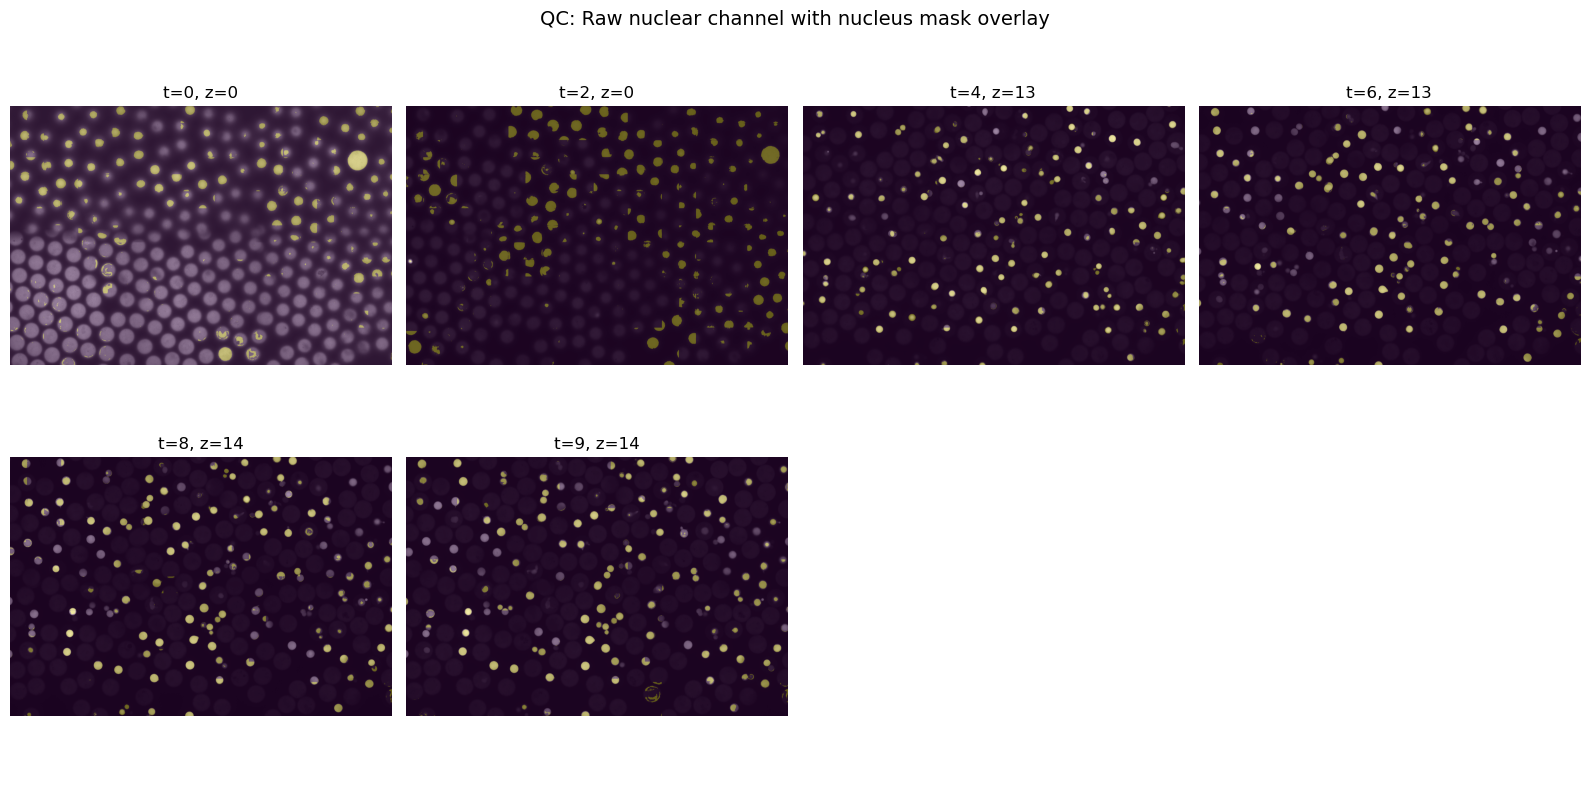

In [21]:
import tifffile as tiff

img_5d = load_image_5d(cfg.input_image_path)

nucleus_instance_4d = tiff.imread(cfg.nucleus_instance_hyperstack_path)
nucleus_mask_4d = nucleus_instance_4d > 0

plot_nucleus_mask_overlay_qc(
    img_5d=img_5d,
    nucleus_mask_4d=nucleus_mask_4d,
    config=cfg,
    timepoints=[0, 2, 4, 6, 8, 9],
    z_mode="max_mask"
)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours


def plot_nucleus_mask_qc_summary(
    nucleus_mask_4d: np.ndarray,
    timepoints=None,
    z_mode: str = "max_mask",
    max_cols: int = 4
) -> None:
    """
    QC summary for binary nucleus masks.

    Top: selected mask snapshots with object outlines
    Bottom: total segmented nuclear area vs time
    """
    T, Z, Y, X = nucleus_mask_4d.shape

    if timepoints is None:
        n_show = min(T, 6)
        timepoints = np.linspace(0, T - 1, n_show, dtype=int).tolist()

    n_panels = len(timepoints)
    n_cols = min(max_cols, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig = plt.figure(figsize=(4 * n_cols, 4 * (n_rows + 1)))
    gs = fig.add_gridspec(n_rows + 1, n_cols)

    panel_axes = []
    for r in range(n_rows):
        for c in range(n_cols):
            panel_axes.append(fig.add_subplot(gs[r, c]))

    for ax, t_idx in zip(panel_axes, timepoints):
        if z_mode == "middle":
            z_idx = Z // 2
        elif z_mode == "max_mask":
            z_sums = nucleus_mask_4d[t_idx].reshape(Z, -1).sum(axis=1)
            z_idx = int(np.argmax(z_sums))
        else:
            raise ValueError("z_mode must be 'middle' or 'max_mask'")

        mask_plane = nucleus_mask_4d[t_idx, z_idx].astype(bool)
        labeled = label(mask_plane)

        ax.imshow(mask_plane, cmap="gray")

        for contour in find_contours(mask_plane.astype(float), level=0.5):
            ax.plot(contour[:, 1], contour[:, 0], linewidth=0.5)

        ax.set_title(f"t={t_idx}, z={z_idx}\nobjects={labeled.max()}")
        ax.axis("off")

    for ax in panel_axes[n_panels:]:
        ax.axis("off")

    area_ax = fig.add_subplot(gs[n_rows, :])
    total_area_px = nucleus_mask_4d.reshape(T, -1).sum(axis=1)
    area_ax.plot(np.arange(T), total_area_px, marker="o")
    area_ax.set_xlabel("Time index")
    area_ax.set_ylabel("Total nucleus mask area (px)")
    area_ax.set_title("QC: Total segmented nuclear area over time")

    plt.tight_layout()
    plt.show()

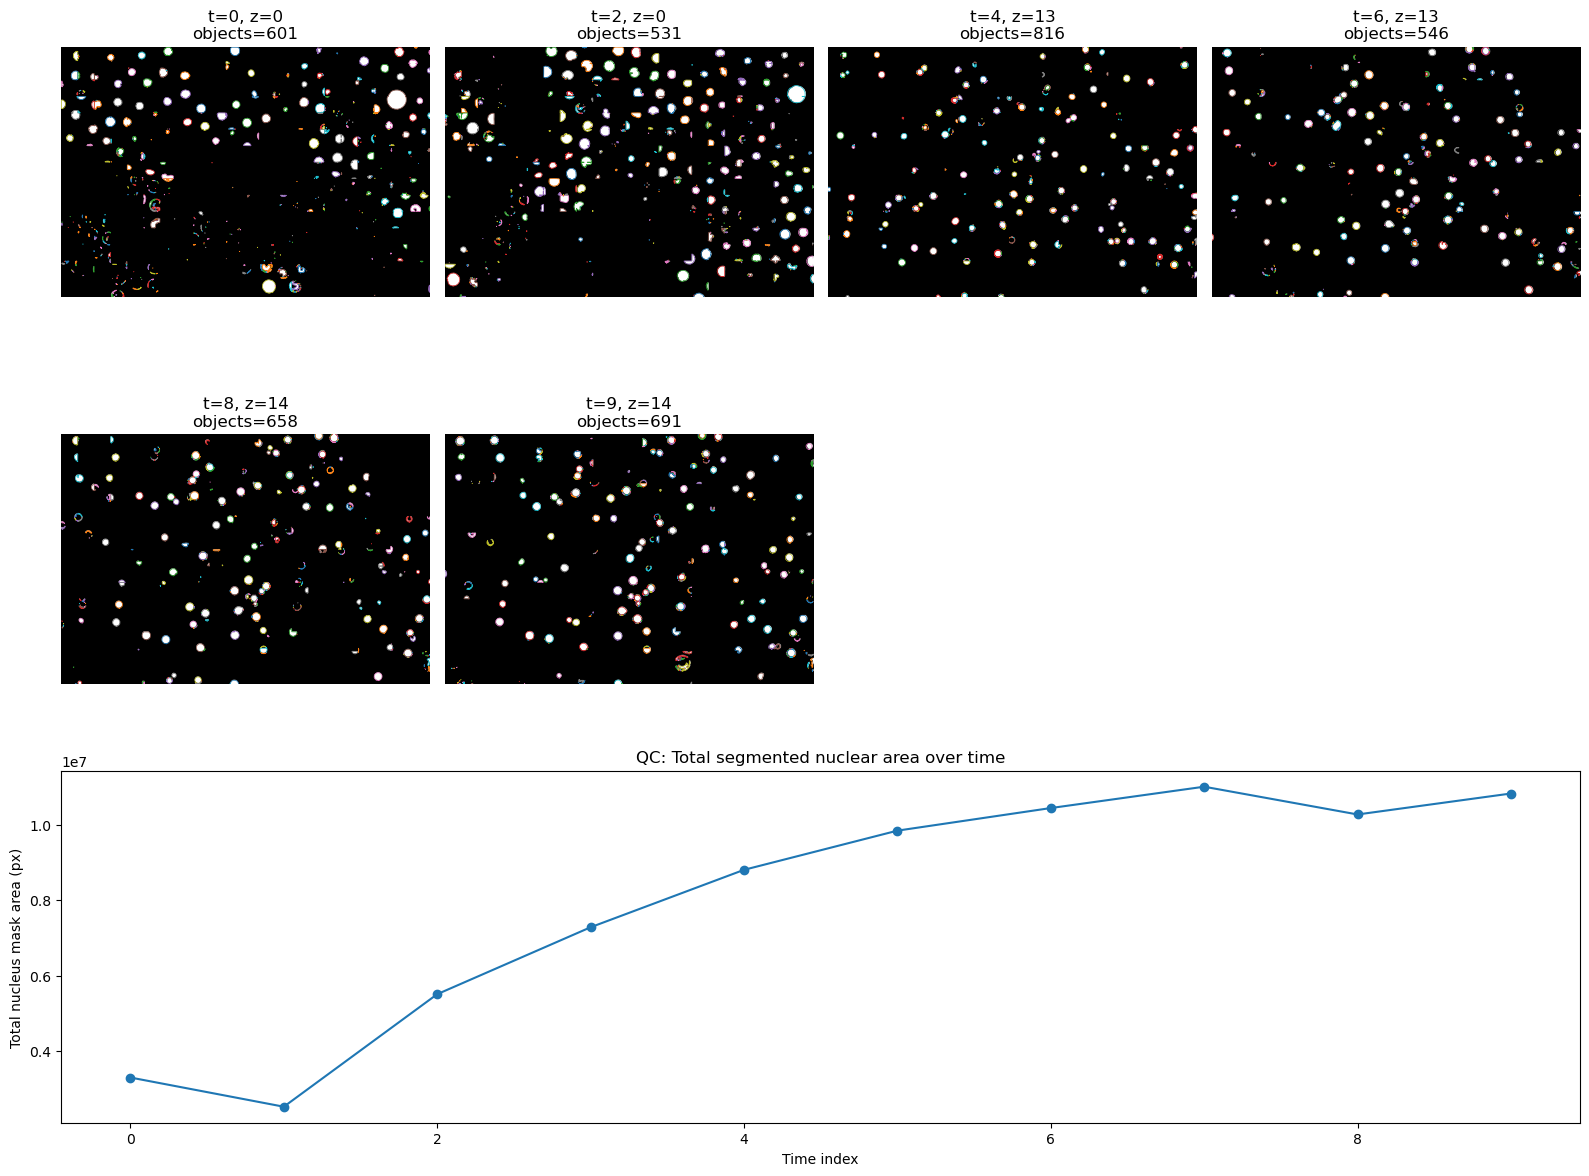

In [25]:
plot_nucleus_mask_qc_summary(
    nucleus_mask_4d=nucleus_mask_4d,
    timepoints=[0, 2, 4, 6, 8, 9],
    z_mode="max_mask"
)

In [23]:
from skimage.measure import label
import numpy as np
import matplotlib.pyplot as plt


def plot_nucleus_count_over_time(nucleus_mask_4d: np.ndarray) -> None:
    """
    Count connected nucleus objects across all z slices for each timepoint.
    """
    T, Z, Y, X = nucleus_mask_4d.shape
    counts = []

    for t_idx in range(T):
        count_t = 0
        for z_idx in range(Z):
            count_t += label(nucleus_mask_4d[t_idx, z_idx].astype(bool)).max()
        counts.append(count_t)

    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(T), counts, marker="o")
    plt.xlabel("Time index")
    plt.ylabel("Connected nucleus objects")
    plt.title("QC: Connected nucleus object count over time")
    plt.tight_layout()
    plt.show()

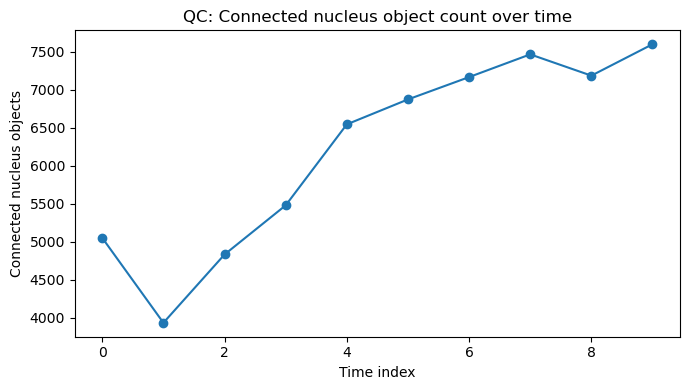

In [24]:
plot_nucleus_count_over_time(nucleus_mask_4d)

In [26]:

import matplotlib.pyplot as plt

def plot_nc_vs_time(halo_df: pd.DataFrame) -> None:
    if halo_df.empty:
        print("No data to plot.")
        return

    plt.figure(figsize=(7, 4))
    for track_id, df_track in halo_df.groupby("track_id"):
        df_track = df_track.sort_values("true_time_min")
        plt.plot(df_track["true_time_min"], df_track["nc_ratio_fraction"], marker="o", label=f"Track {track_id}")
    plt.xlabel("True acquisition time (min)")
    plt.ylabel("N / (N + C)")
    plt.title("N/C ratio fraction by track")
    plt.tight_layout()
    plt.show()

def plot_area_vs_time(halo_df: pd.DataFrame) -> None:
    if halo_df.empty:
        print("No data to plot.")
        return

    plt.figure(figsize=(7, 4))
    for track_id, df_track in halo_df.groupby("track_id"):
        df_track = df_track.sort_values("true_time_min")
        plt.plot(df_track["true_time_min"], df_track["nucleus_area_um2"], marker="o", label=f"Track {track_id}")
    plt.xlabel("True acquisition time (min)")
    plt.ylabel("Nuclear area (µm²)")
    plt.title("Largest nuclear cross-sectional area by track")
    plt.tight_layout()
    plt.show()


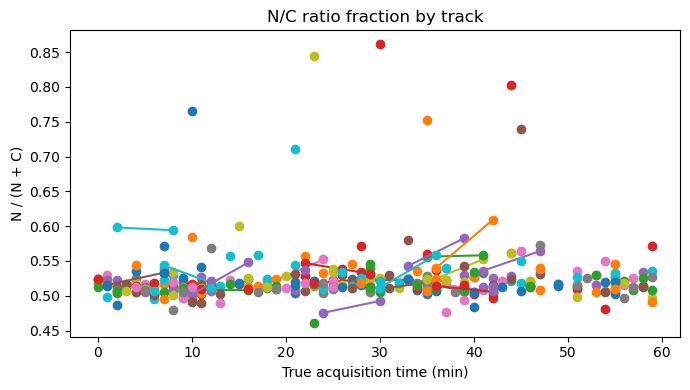

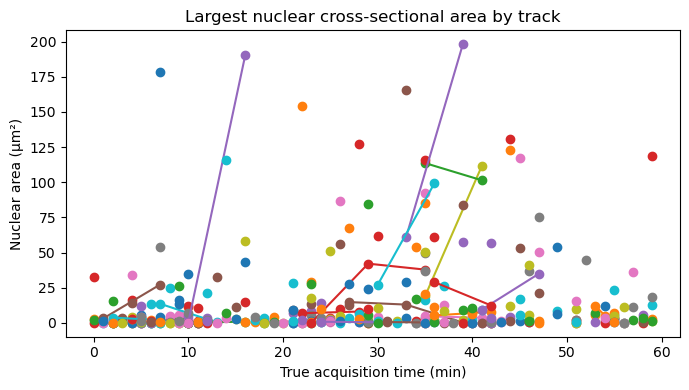

In [27]:
plot_nc_vs_time(halo_df)
plot_area_vs_time(halo_df)

In [28]:
model = load_unet_model(cfg.model_path)

print("Model loaded")

Model loaded


In [29]:
def plot_nucleus_probability_qc(
    class_prob_map: np.ndarray,
    raw_plane: np.ndarray,
    title=""
):
    """
    class_prob_map: (Y, X, C)
    """
    nucleus_prob = class_prob_map[..., 2]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(raw_plane, cmap="gray")
    plt.title("Raw")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(nucleus_prob, cmap="inferno")
    plt.title("Nucleus probability")
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.hist(nucleus_prob.ravel(), bins=100)
    plt.title("Probability distribution")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

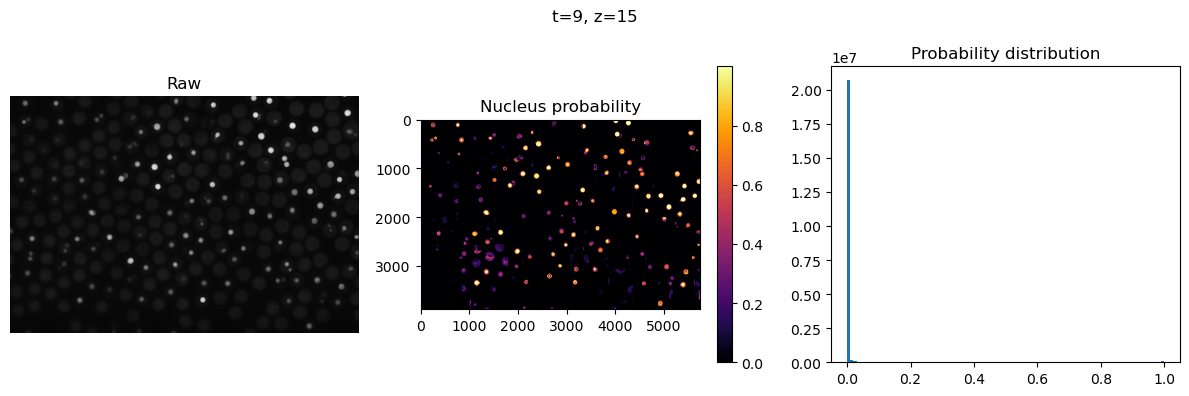

In [29]:
t_idx = 9
z_idx = 15

plane_yxc = get_full_plane_yxc(img_5d, t_idx, z_idx)

class_prob_map, class_label_map, nucleus_mask, _ = segment_single_plane_with_overlap(
    plane_yxc,
    model,
    cfg
)

raw_plane = plane_yxc[..., cfg.nuclear_channel_index]

plot_nucleus_probability_qc(
    class_prob_map,
    raw_plane,
    title=f"t={t_idx}, z={z_idx}"
)

In [30]:
t_idx = 9
z_idx = 15

plane_yxc = get_full_plane_yxc(img_5d, t_idx, z_idx)

class_prob_map, class_label_map, nucleus_mask, _ = segment_single_plane_with_overlap(
    plane_yxc,
    model,
    cfg
)

# 🔥 THIS is what you were missing
nucleus_prob = class_prob_map[..., cfg.nucleus_class_index]

In [36]:
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    mask = nucleus_prob > thresh

    print(f"Threshold {thresh}: pixels =", mask.sum())

Threshold 0.1: pixels = 1139978
Threshold 0.2: pixels = 891589
Threshold 0.3: pixels = 718385
Threshold 0.4: pixels = 580012
Threshold 0.5: pixels = 451939


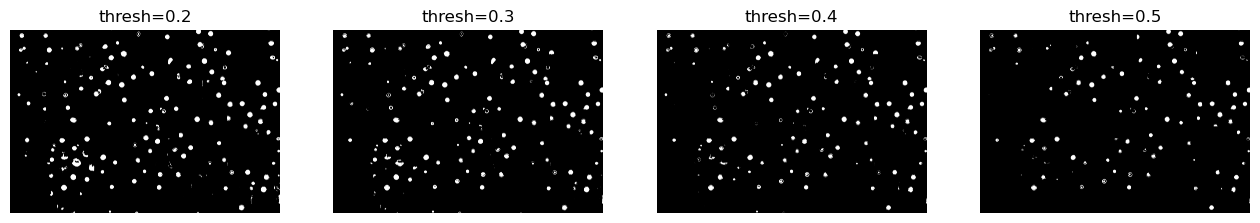

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))

for ax, thresh in zip(axes, [0.2, 0.3, 0.4, 0.5]):
    mask = nucleus_prob > thresh
    ax.imshow(mask, cmap="gray")
    ax.set_title(f"thresh={thresh}")
    ax.axis("off")

plt.show()

In [31]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_largest_cross_sectional_area_vs_time(best_z_df: pd.DataFrame) -> None:
    """
    Plot the largest cross-sectional nuclear area for all nuclei as a function of time.

    Expects best_z_df to contain:
        - true_time_min
        - area_px
        or nucleus_area_um2

    If nucleus_area_um2 is not present, it will be computed from area_px
    using cfg.pixel_size_um.
    """
    if best_z_df.empty:
        print("No data to plot.")
        return

    plot_df = best_z_df.copy()

    if "nucleus_area_um2" not in plot_df.columns:
        if "area_px" not in plot_df.columns:
            raise ValueError("best_z_df must contain either 'nucleus_area_um2' or 'area_px'.")
        plot_df["nucleus_area_um2"] = plot_df["area_px"] * (cfg.pixel_size_um ** 2)

    if "true_time_min" not in plot_df.columns:
        raise ValueError("best_z_df must contain 'true_time_min'.")

    plot_df = plot_df.sort_values("true_time_min")

    mean_df = (
        plot_df.groupby("true_time_min", as_index=False)["nucleus_area_um2"]
        .mean()
        .rename(columns={"nucleus_area_um2": "mean_nucleus_area_um2"})
    )

    plt.figure(figsize=(8, 5))
    plt.scatter(
        plot_df["true_time_min"],
        plot_df["nucleus_area_um2"],
        alpha=0.35,
        s=20
    )
    plt.plot(
        mean_df["true_time_min"],
        mean_df["mean_nucleus_area_um2"],
        linewidth=2
    )
    plt.xlabel("True acquisition time (min)")
    plt.ylabel("Largest cross-sectional nuclear area (µm²)")
    plt.title("Largest cross-sectional nuclear area vs time")
    plt.tight_layout()
    plt.show()

In [36]:
plot_largest_cross_sectional_area_vs_time(best_z_df)

ValueError: best_z_df must contain 'true_time_min'.

In [35]:
halo_df = results["halo_df"]
best_z_df = results["best_z_df"]
timings_df = results["timings_df"]

In [37]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_largest_cross_sectional_area_vs_time(timed_df: pd.DataFrame) -> None:
    """
    Plot largest cross-sectional nuclear area for all nuclei as a function of time.

    Expects timed_df to contain:
        - true_time_min
        - area_px or nucleus_area_um2
    """
    if timed_df.empty:
        print("No data to plot.")
        return

    plot_df = timed_df.copy()

    if "nucleus_area_um2" not in plot_df.columns:
        if "area_px" not in plot_df.columns:
            raise ValueError("timed_df must contain either 'nucleus_area_um2' or 'area_px'.")
        plot_df["nucleus_area_um2"] = plot_df["area_px"] * (cfg.pixel_size_um ** 2)

    if "true_time_min" not in plot_df.columns:
        raise ValueError("timed_df must contain 'true_time_min'.")

    plot_df = plot_df.sort_values("true_time_min")

    mean_df = (
        plot_df.groupby("true_time_min", as_index=False)["nucleus_area_um2"]
        .mean()
        .rename(columns={"nucleus_area_um2": "mean_nucleus_area_um2"})
    )

    plt.figure(figsize=(8, 5))
    plt.scatter(
        plot_df["true_time_min"],
        plot_df["nucleus_area_um2"],
        alpha=0.35,
        s=20
    )
    plt.plot(
        mean_df["true_time_min"],
        mean_df["mean_nucleus_area_um2"],
        linewidth=2
    )
    plt.xlabel("True acquisition time (min)")
    plt.ylabel("Largest cross-sectional nuclear area (µm²)")
    plt.title("Largest cross-sectional nuclear area vs time")
    plt.tight_layout()
    plt.show()

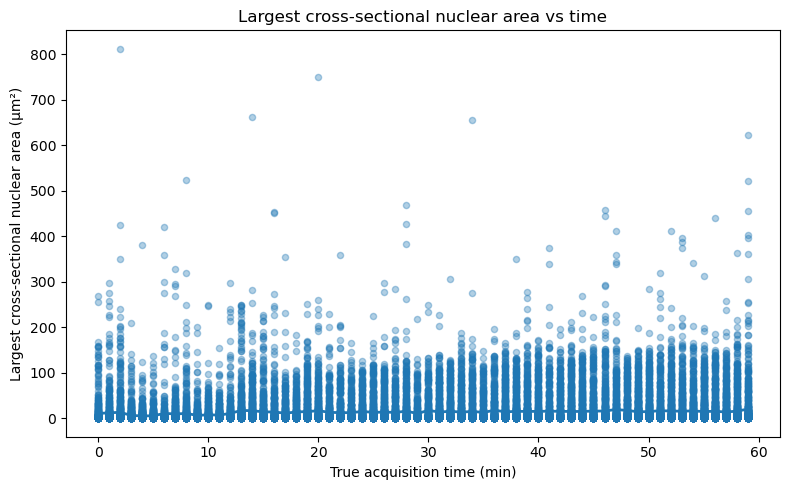

In [42]:
timed_df = results["timed_df"]
plot_largest_cross_sectional_area_vs_time(timed_df)

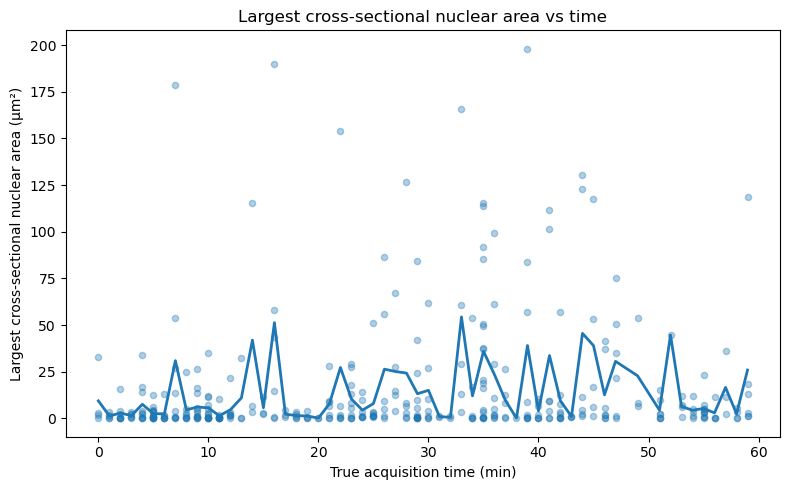

In [39]:
tracked_df = results["tracked_df"]
plot_largest_cross_sectional_area_vs_time(tracked_df)

In [40]:
def filter_nuclei_by_area(df: pd.DataFrame,
                         min_area_um2: float = 100,
                         max_area_um2: float = 300) -> pd.DataFrame:
    """
    Remove objects that are too small or too large to be nuclei.
    """
    df = df.copy()

    if "nucleus_area_um2" not in df.columns:
        df["nucleus_area_um2"] = df["area_px"] * (cfg.pixel_size_um ** 2)

    filtered = df[
        (df["nucleus_area_um2"] >= min_area_um2) &
        (df["nucleus_area_um2"] <= max_area_um2)
    ]

    print(f"Filtered: {len(df)} → {len(filtered)} nuclei")

    return filtered

In [41]:
timed_df = results["timed_df"]

filtered_df = filter_nuclei_by_area(
    timed_df,
    min_area_um2=100,
    max_area_um2=300
)

Filtered: 36743 → 1196 nuclei



## 21. HPC notes

Even though this is packaged as a notebook, the logic is intentionally modular so it can be ported to batch jobs later.

### Recommended cluster strategy
- **GPU job** for U-Net inference
- **CPU / multicore jobs** for:
  - object extraction
  - z grouping
  - exclusion filtering
  - time correction
  - tracking
  - halo analysis
  - radial sweep analysis

### Good intermediate files
- `segmentation_index.pkl`
- `plane_objects.pkl`
- `grouped_z_objects.pkl`
- `best_z_nuclei.pkl`
- `tracked_nuclei.pkl`
- `halo_analysis.pkl`
- `pipeline_timings.pkl`
